# Bài Toán Phân Công Giảng Viên - SO SÁNH 2 GIẢI PHÁP

Tập tin này chứa toàn bộ mã nguồn **C++** và **Python trực quan hóa** cho 2 giải thuật:
1. Giải thuật **Đường tăng luồng bằng Đệ quy DFS** ($O(V \times E)$)
2. Giải thuật **Hopcroft-Karp** ($O(E \sqrt{V})$)

---
##  PHẦN 1: Giải pháp 1 - Thuật toán DFS (Đường tăng luồng cơ bản)

In [1]:
%%writefile dfs.cpp
#include <iostream>
#include <vector>
#include <iomanip>

using namespace std;

// Hàm đệ quy DFS tìm đường tăng luồng
bool dfs(int u, const vector<vector<bool>>& bpGraph, vector<int>& matchR, vector<bool>& seen, int N) {
    for (int v = 0; v < N; v++) {
        if (bpGraph[u][v] && !seen[v]) {
            seen[v] = true;
            if (matchR[v] < 0 || dfs(matchR[v], bpGraph, matchR, seen, N)) {
                matchR[v] = u;
                return true;
            }
        }
    }
    return false;
}

void maxBPM(const vector<vector<bool>>& bpGraph, int M, int N) {
    vector<int> matchR(N, -1);
    int result = 0;

    for (int u = 0; u < M; u++) {
        vector<bool> seen(N, false);
        if (dfs(u, bpGraph, matchR, seen, N)) {
            result++;
        }
    }

    cout << "\n================ KET QUA PHAN CONG (DFS) ================\n";
    cout << "Tong so khoa hoc duoc phan cong: " << result << " / " << N << "\n";
    cout << "---------------------------------------------------------\n";
    cout << left << setw(15) << "KHOA HOC" << " | " << "GIANG VIEN PHU TRACH" << "\n";
    cout << "---------------------------------------------------------\n";
    for (int v = 0; v < N; v++) {
        if (matchR[v] != -1) {
            cout << left << setw(15) << ("Khoa hoc C" + to_string(v + 1))
                 << " | " << "Giang vien G" << matchR[v] + 1 << "\n";
        } else {
            cout << left << setw(15) << ("Khoa hoc C" + to_string(v + 1))
                 << " | " << "[Chua co giang vien]" << "\n";
        }
    }
    cout << "=========================================================\n";
}

int main() {
    int M = 4, N = 4;
    vector<vector<bool>> bpGraph = {
        {0, 1, 1, 0}, // G1
        {1, 0, 0, 1}, // G2
        {0, 0, 1, 0}, // G3
        {0, 0, 0, 1}  // G4
    };
    maxBPM(bpGraph, M, N);
    return 0;
}


Writing dfs.cpp


In [2]:
!g++ dfs.cpp -o dfs
!./dfs


================ KET QUA PHAN CONG (DFS) ================
Tong so khoa hoc duoc phan cong: 4 / 4
---------------------------------------------------------
KHOA HOC        | GIANG VIEN PHU TRACH
---------------------------------------------------------
Khoa hoc C1     | Giang vien G2
Khoa hoc C2     | Giang vien G1
Khoa hoc C3     | Giang vien G3
Khoa hoc C4     | Giang vien G4


###  Trực quan hóa và Kiểm tra (DFS Output)
Khởi chạy đoạn mã Python dưới đây để vẽ Sơ đồ mạng lưới và bảng tự động đối chiếu Tích xanh/Tích đỏ.

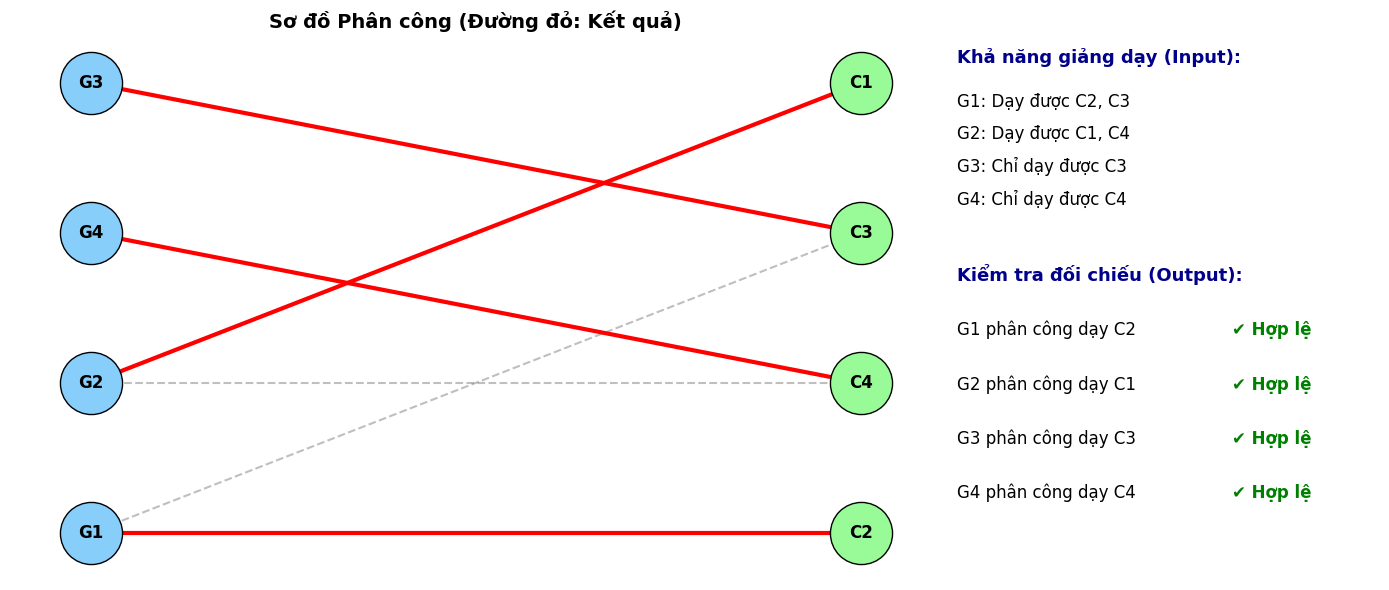

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

giang_vien = ['G1', 'G2', 'G3', 'G4']
khoa_hoc = ['C1', 'C2', 'C3', 'C4']
all_edges = [('G1', 'C2'), ('G1', 'C3'), ('G2', 'C1'), ('G2', 'C4'), ('G3', 'C3'), ('G4', 'C4')]
matched_edges = [('G2', 'C1'), ('G1', 'C2'), ('G3', 'C3'), ('G4', 'C4')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2.2, 1]})

B = nx.Graph()
B.add_nodes_from(giang_vien, bipartite=0)
B.add_nodes_from(khoa_hoc, bipartite=1)
B.add_edges_from(all_edges)

pos = nx.bipartite_layout(B, giang_vien)
nx.draw_networkx_edges(B, pos, edgelist=all_edges, edge_color='gray', style='dashed', alpha=0.5, width=1.5, ax=ax1)
nx.draw_networkx_edges(B, pos, edgelist=matched_edges, edge_color='red', width=3, ax=ax1)
nx.draw_networkx_nodes(B, pos, nodelist=giang_vien, node_color='#87CEFA', node_size=2000, edgecolors='black', ax=ax1)
nx.draw_networkx_nodes(B, pos, nodelist=khoa_hoc, node_color='#98FB98', node_size=2000, edgecolors='black', ax=ax1)
nx.draw_networkx_labels(B, pos, font_size=12, font_weight='bold', ax=ax1)

ax1.set_title("Sơ đồ Phân công (Đường đỏ: Kết quả)", fontsize=14, fontweight='bold')
ax1.axis('off')

ax2.axis('off')
y = 0.95
ax2.text(0, y, "Khả năng giảng dạy (Input):", fontsize=13, fontweight='bold', color='darkblue')
ax2.text(0, y-0.08, "G1: Dạy được C2, C3", fontsize=12)
ax2.text(0, y-0.14, "G2: Dạy được C1, C4", fontsize=12)
ax2.text(0, y-0.20, "G3: Chỉ dạy được C3", fontsize=12)
ax2.text(0, y-0.26, "G4: Chỉ dạy được C4", fontsize=12)

y -= 0.40
ax2.text(0, y, "Kiểm tra đối chiếu (Output):", fontsize=13, fontweight='bold', color='darkblue')

capabilities = {'G1': ['C2', 'C3'], 'G2': ['C1', 'C4'], 'G3': ['C3'], 'G4': ['C4']}
matched_dict = dict(matched_edges)

for g in giang_vien:
    y -= 0.1
    c = matched_dict.get(g)
    ax2.text(0, y, f"{g} phân công dạy {c}", fontsize=12)
    if c in capabilities[g]:
        ax2.text(0.65, y, "✔ Hợp lệ", fontsize=12, color='green', fontweight='bold')
    else:
        ax2.text(0.65, y, "✘ Lỗi", fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.show()


---
##  PHẦN 2: Giải pháp 2 - Thuật toán Hopcroft-Karp (Tối ưu nhất)

In [4]:
%%writefile hopcroft_karp.cpp
#include <iostream>
#include <vector>
#include <queue>
#include <iomanip>

using namespace std;
const int INF = 1e9;

class HopcroftKarp {
    int m, n;
    vector<vector<int>> adj;
    vector<int> pairU, pairV, dist;

public:
    HopcroftKarp(int m, int n) : m(m), n(n) {
        adj.resize(m + 1);
        pairU.assign(m + 1, 0);
        pairV.assign(n + 1, 0);
        dist.assign(m + 1, 0);
    }

    void addEdge(int u, int v) {
        adj[u].push_back(v);
    }

    bool bfs() {
        queue<int> q;
        for (int u = 1; u <= m; u++) {
            if (pairU[u] == 0) {
                dist[u] = 0;
                q.push(u);
            } else {
                dist[u] = INF;
            }
        }
        dist[0] = INF;
        while (!q.empty()) {
            int u = q.front();
            q.pop();
            if (dist[u] < dist[0]) {
                for (int v : adj[u]) {
                    if (dist[pairV[v]] == INF) {
                        dist[pairV[v]] = dist[u] + 1;
                        q.push(pairV[v]);
                    }
                }
            }
        }
        return (dist[0] != INF);
    }

    bool dfs(int u) {
        if (u != 0) {
            for (int v : adj[u]) {
                if (dist[pairV[v]] == dist[u] + 1) {
                    if (dfs(pairV[v])) {
                        pairV[v] = u;
                        pairU[u] = v;
                        return true;
                    }
                }
            }
            dist[u] = INF;
            return false;
        }
        return true;
    }

    int maxMatching() {
        int result = 0;
        while (bfs()) {
            for (int u = 1; u <= m; u++) {
                if (pairU[u] == 0 && dfs(u)) {
                    result++;
                }
            }
        }
        return result;
    }

    void printResult() {
        int res = maxMatching();
        cout << "\n=========== KET QUA PHAN CONG (HOPCROFT-KARP) ===========\n";
        cout << "Tong so khoa hoc duoc phan cong: " << res << " / " << n << "\n";
        cout << "---------------------------------------------------------\n";
        cout << left << setw(15) << "KHOA HOC" << " | " << "GIANG VIEN PHU TRACH" << "\n";
        cout << "---------------------------------------------------------\n";
        for (int v = 1; v <= n; v++) {
            if (pairV[v] != 0) {
                cout << left << setw(15) << ("Khoa hoc C" + to_string(v))
                     << " | Giang vien G" << pairV[v] << "\n";
            }
        }
        cout << "=========================================================\n";
    }
};

int main() {
    HopcroftKarp hk(4, 4);
    hk.addEdge(1, 2); hk.addEdge(1, 3);
    hk.addEdge(2, 1); hk.addEdge(2, 4);
    hk.addEdge(3, 3);
    hk.addEdge(4, 4);

    hk.printResult();
    return 0;
}


Writing hopcroft_karp.cpp


In [5]:
!g++ hopcroft_karp.cpp -o hopcroft_karp
!./hopcroft_karp


=========== KET QUA PHAN CONG (HOPCROFT-KARP) ===========
Tong so khoa hoc duoc phan cong: 4 / 4
---------------------------------------------------------
KHOA HOC        | GIANG VIEN PHU TRACH
---------------------------------------------------------
Khoa hoc C1     | Giang vien G2
Khoa hoc C2     | Giang vien G1
Khoa hoc C3     | Giang vien G3
Khoa hoc C4     | Giang vien G4


###  Trực quan hóa và Kiểm tra (Hopcroft-Karp Output)

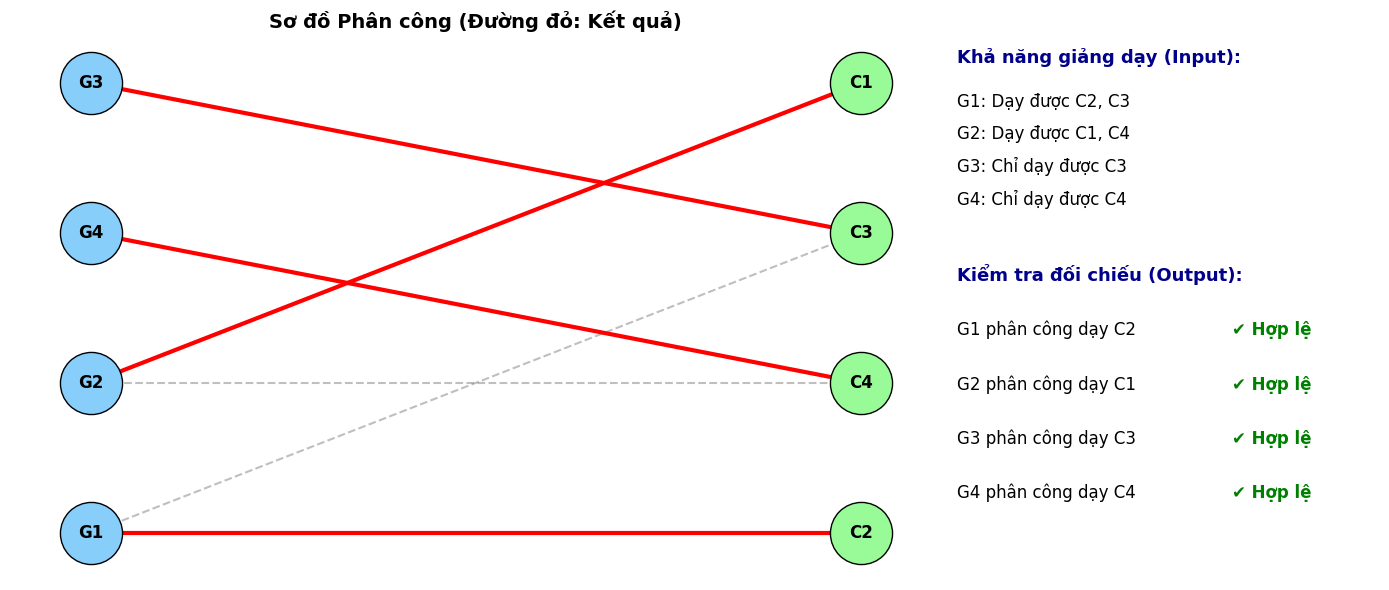

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

giang_vien = ['G1', 'G2', 'G3', 'G4']
khoa_hoc = ['C1', 'C2', 'C3', 'C4']
all_edges = [('G1', 'C2'), ('G1', 'C3'), ('G2', 'C1'), ('G2', 'C4'), ('G3', 'C3'), ('G4', 'C4')]
matched_edges = [('G2', 'C1'), ('G1', 'C2'), ('G3', 'C3'), ('G4', 'C4')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2.2, 1]})

B = nx.Graph()
B.add_nodes_from(giang_vien, bipartite=0)
B.add_nodes_from(khoa_hoc, bipartite=1)
B.add_edges_from(all_edges)

pos = nx.bipartite_layout(B, giang_vien)
nx.draw_networkx_edges(B, pos, edgelist=all_edges, edge_color='gray', style='dashed', alpha=0.5, width=1.5, ax=ax1)
nx.draw_networkx_edges(B, pos, edgelist=matched_edges, edge_color='red', width=3, ax=ax1)
nx.draw_networkx_nodes(B, pos, nodelist=giang_vien, node_color='#87CEFA', node_size=2000, edgecolors='black', ax=ax1)
nx.draw_networkx_nodes(B, pos, nodelist=khoa_hoc, node_color='#98FB98', node_size=2000, edgecolors='black', ax=ax1)
nx.draw_networkx_labels(B, pos, font_size=12, font_weight='bold', ax=ax1)

ax1.set_title("Sơ đồ Phân công (Đường đỏ: Kết quả)", fontsize=14, fontweight='bold')
ax1.axis('off')

ax2.axis('off')
y = 0.95
ax2.text(0, y, "Khả năng giảng dạy (Input):", fontsize=13, fontweight='bold', color='darkblue')
ax2.text(0, y-0.08, "G1: Dạy được C2, C3", fontsize=12)
ax2.text(0, y-0.14, "G2: Dạy được C1, C4", fontsize=12)
ax2.text(0, y-0.20, "G3: Chỉ dạy được C3", fontsize=12)
ax2.text(0, y-0.26, "G4: Chỉ dạy được C4", fontsize=12)

y -= 0.40
ax2.text(0, y, "Kiểm tra đối chiếu (Output):", fontsize=13, fontweight='bold', color='darkblue')

capabilities = {'G1': ['C2', 'C3'], 'G2': ['C1', 'C4'], 'G3': ['C3'], 'G4': ['C4']}
matched_dict = dict(matched_edges)

for g in giang_vien:
    y -= 0.1
    c = matched_dict.get(g)
    ax2.text(0, y, f"{g} phân công dạy {c}", fontsize=12)
    if c in capabilities[g]:
        ax2.text(0.65, y, "✔ Hợp lệ", fontsize=12, color='green', fontweight='bold')
    else:
        ax2.text(0.65, y, "✘ Lỗi", fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.show()
